# Análisis para la cadena de gimnasios Model Fitness

**Propósito del proyecto:**

El propósito del proyecto es aprender a predecir la probabilidad de pérdida del próximo mes para cada cliente mediante machine learning, asi como analizar los factores que más impactan la pérdida.

## Inicialización

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

## Cargar datos

In [ ]:
df = pd.read_csv('/datasets/gym_churn_us.csv')
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0


## Análisis exploratorio de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

Los datos no presentan valores ausentes.

In [ ]:
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


**Variables ausentes pero que pueden ser valiosas:**

Aquí algunas variables que podrían enriquecer la segmentación:
- Satisfacción: Medir experiencias positivas/negativas.
- Motivo de inscripción: Revela intención y emociones iniciales.
- Uso de app o digitalización: Segmenta por tipo de interacción.
- Actividades favoritas: Conecta con gustos y patrones de permanencia.
- Eventos de vida (mudanza, baja): Explican outliers de cancelación o ausencia.

In [ ]:
users_by_validity = df.groupby('Churn').mean()
print(users_by_validity)

         gender  Near_Location   Partner  Promo_friends     Phone  \
Churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       Contract_period  Group_visits        Age  Avg_additional_charges_total  \
Churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       Month_to_end_contract  Lifetime  Avg_class_frequency_total  \
Churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       Avg_class_frequency_current_month  
Churn                                     
0                               2.0

**Conclusiones:**

Esta tabla comparativa entre clientes que cancelaron (Churn = 1) y los que continuaron (Churn = 0) revela insights valiosos para entender los factores que influyen en la permanencia.

1. Ubicación y conexiones sociales marcan diferencia:
- Los clientes que no cancelan tienden a vivir cerca (Near_Location) y tienen más vínculos sociales, es decir, más probabilidad de tener pareja (Partner) y amigos referidos (Promo_friends). Esto sugiere que la cercanía y las redes personales aumentan el sentido de pertenencia, lo que puede reforzar la fidelidad.
2. Compromiso contractual y permanencia:
- La duración del contrato (Contract_period), el tiempo restante (Month_to_end_contract) y la permanencia total (Lifetime) son significativamente mayores en clientes activos. Los contratos largos y rutinas establecidas parecen fortalecer el apego y disminuir el riesgo de abandono.
3. Actividad y participación:
- Los usuarios activos tienen mayores visitas en grupo, más frecuencia de clases actual y acumulada, y más cargos adicionales. Esto refleja que la participación constante y el uso de servicios complementarios están ligados al compromiso emocional con la marca.
4. Variables sociodemográficas y edad:
- No hay diferencias importantes en género y teléfono, pero sí en edad, los que cancelan son en promedio 3 años más jóvenes. Esto podría indicar que los usuarios más jóvenes tienen menos arraigo o menor estabilidad en hábitos de consumo.

Este perfil indica que la retención se construye a partir de hábitos, vínculos personales y experiencias compartidas. Reforzar el compromiso en el primer mes con retos, beneficios por traer amigos, o experiencias de grupo puede ser decisivo.

### Histogramas

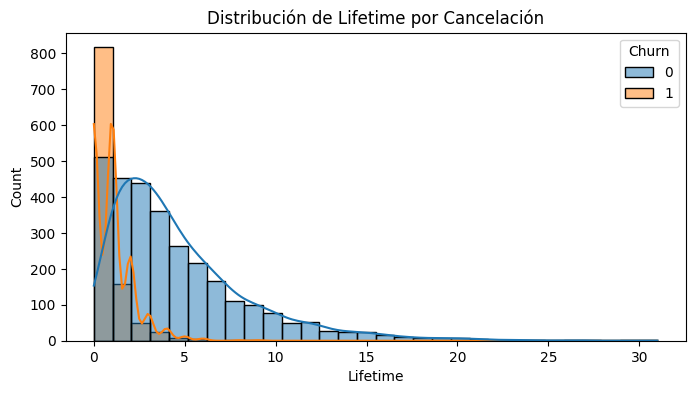

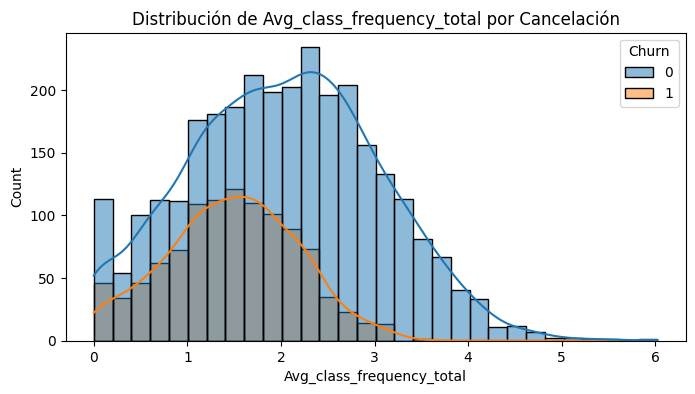

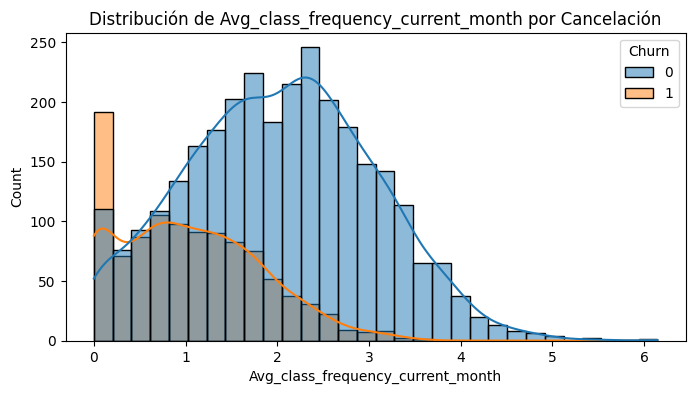

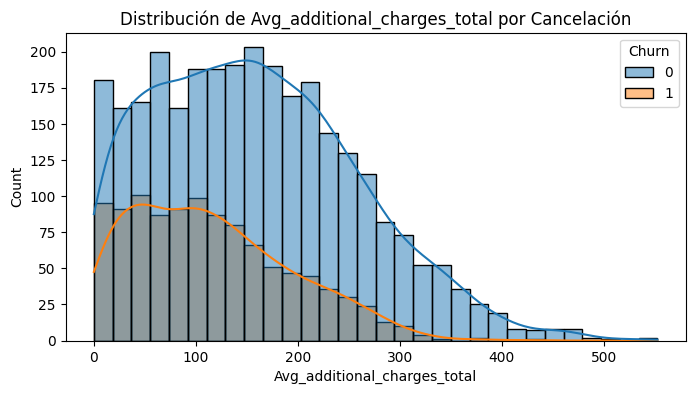

In [ ]:
features = ['Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'Avg_additional_charges_total']
for feature in features:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=feature, hue='Churn', kde=True, bins=30)
    plt.title(f'Distribución de {feature} por Cancelación')
    plt.show()

**Conclusiones:**

Los gráficos revelan patrones clave asociados a la cancelación de membresías:
- Duración de permanencia (Lifetime):
Los clientes que cancelan tienden a tener una permanencia muy corta. Esto indica que el riesgo de abandono es especialmente alto en los primeros meses. En cambio, quienes permanecen muestran una distribución más amplia, lo que sugiere que superar cierto umbral de tiempo mejora la retención.
- Frecuencia total de asistencia (Avg_class_frequency_total):
La frecuencia promedio de clases es significativamente más baja entre quienes abandonan el gimnasio. Por el contrario, los clientes que asisten con más regularidad parecen estar más comprometidos y menos propensos a cancelar.
- Frecuencia mensual actual de clases (Avg_class_frequency_current_month):
Los clientes que cancelaron su membresía presentan una frecuencia de clases casi nula. En cambio, quienes se mantienen activos tienden a asistir entre 2 y 3 veces por mes. Esto confirma que la desvinculación empieza cuando se rompe el hábito.
- Cargos adicionales totales (Avg_additional_charges_total):
Quienes cancelan muestran menor gasto en servicios extra. Esto sugiere que un bajo nivel de compromiso financiero y emocional con el gimnasio precede a la decisión de cancelar.

### Matriz de correlación

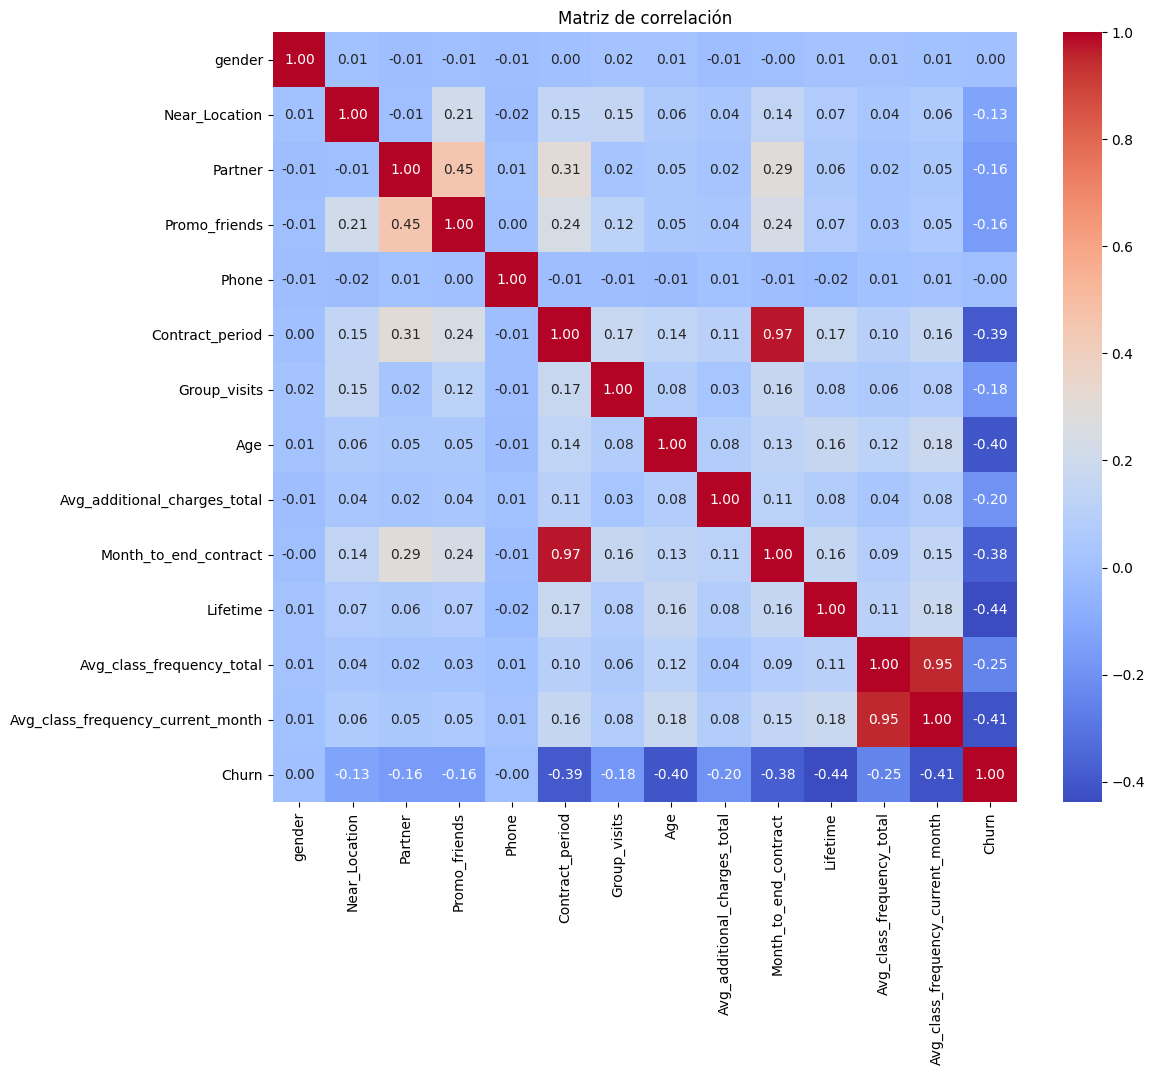

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación')
plt.show()

**Conclusiones:**

La matriz revela patrones de relación entre variables que permiten anticipar el riesgo de cancelación (churn) y entender mejor el comportamiento del cliente. Destacan tres hallazgos:
- Compromiso contractual:
La variable Contract_period tiene una alta correlación positiva con Month_to_end_contract (0.97) y una negativa con Churn (-0.39). Esto sugiere que los contratos largos tienden a retener más a los usuarios, ya sea por compromiso o por menor propensión a abandonar en etapas tempranas.
- Frecuencia y duración como motores de retención:
Avg_class_frequency_total y Lifetime se correlacionan negativamente con Churn, lo que indica que cuanto mayor es la frecuencia acumulada y la duración total de la membresía, menor es el riesgo de cancelación. La constancia construye apego.
- Cargos adicionales como indicador de vinculación emocional:
Avg_additional_charges_total también se correlaciona negativamente con Churn, lo que implica que quienes invierten más en servicios extra están más conectados emocionalmente con la experiencia, y son menos propensos a abandonarla.

## Modelo de predicción de cancelación

In [ ]:
df_encoded = pd.get_dummies(df)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

# Regresión logística
log_model = LogisticRegression(random_state = 0)
log_model.fit(X_train_st, y_train)
y_pred = log_model.predict(X_test_st)

acc_log = accuracy_score(y_test, y_pred)
prec_log = precision_score(y_test, y_pred)
rec_log = recall_score(y_test, y_pred)

# Bosque aleatorio
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 0)
rf_model.fit(X_train_st, y_train)
y_pred_rf = rf_model.predict(X_test_st)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)

# Mostrar resultados
print("Regresión Logística:")
print(f"Exactitud: {acc_log:.2f}, Precisión: {prec_log:.2f}, Recall: {rec_log:.2f}")

print("\nBosque Aleatorio:")
print(f"Exactitud: {acc_rf:.2f}, Precisión: {prec_rf:.2f}, Recall: {rec_rf:.2f}")

Regresión Logística:
Exactitud: 0.92, Precisión: 0.85, Recall: 0.83

Bosque Aleatorio:
Exactitud: 0.92, Precisión: 0.84, Recall: 0.81


**Conclusiones:**

Regresión Logística se desempeña ligeramente mejor en precisión y recall, lo que indica:
- Menor probabilidad de falsos positivos.
- Mejor capacidad para detectar verdaderos positivos.

Además, al ser un modelo más interpretativo, permite visualizar la influencia de cada variable (coeficientes).

## Crear clústeres de usuarios

### Dendrograma

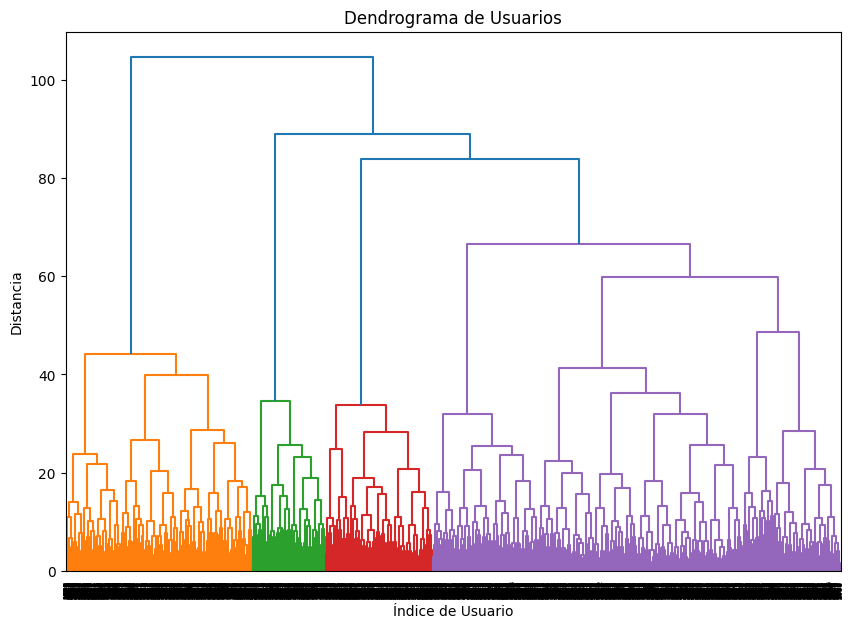

In [ ]:
X_scaled = scaler.fit_transform(X)

linked = linkage(X_scaled, method = 'ward')

plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top')
plt.title('Dendrograma de Usuarios')
plt.xlabel('Índice de Usuario')
plt.ylabel('Distancia')
plt.show()

### Modelo K-means

In [ ]:
kmeans = KMeans(n_clusters=5)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

cluster_means = df.groupby('cluster').mean()
print(cluster_means)

           gender  Near_Location   Partner  Promo_friends  Phone  \
cluster                                                            
0        0.523316       0.862694  0.471503       0.305699    0.0   
1        0.501481       0.960513  0.782823       0.573544    1.0   
2        0.485437       1.000000  0.350324       0.237055    1.0   
3        0.558275       0.977855  0.355478       0.235431    1.0   
4        0.497041       0.000000  0.461538       0.078895    1.0   

         Contract_period  Group_visits        Age  \
cluster                                             
0               4.777202      0.427461  29.297927   
1              10.892399      0.541955  29.981244   
2               1.960356      0.339806  28.145631   
3               2.585082      0.470862  30.104895   
4               2.378698      0.218935  28.479290   

         Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
cluster                                                                  
0  

**Conclusiones:**

El agrupamiento revela diferencias marcadas entre perfiles de clientes en cuanto a compromiso, entorno social, y riesgo de cancelación:

Clúster 0
- Alta presencia cerca del gimnasio (96%) y vínculos laborales (78% Partner).
- Contratos largos (∼11 meses), frecuentes visitas grupales y alto gasto extra.
- Tasa de cancelación muy baja (2.8%).
- Interpretación: Este grupo está arraigado emocional y físicamente; son clientes leales con hábitos consolidados.

Clúster 1
- Cero cercanía física (0%), pocos vínculos sociales (solo 8% Promo_friends), contratos cortos.
- Cancelación alta: 44%.
- Interpretación: Su aislamiento tanto geográfico como emocional reduce el apego al gimnasio.

Clúster 2
- Buena cercanía (86%) y gasto medio, con contratos moderados (∼5 meses) y cancelación del 27%.
- Interpretación: Si se refuerza su vinculación, podrían fidelizarse más.

Clúster 3
- Alta frecuencia de clases (2.8 veces/semana) y el mayor gasto extra.
- Tasa de cancelación muy baja (7%), a pesar del contrato corto.
- Interpretación: La motivación viene desde dentro. El hábito eclipsa el largo del contrato.

Clúster 4
- 100% viven cerca, pero tienen contratos cortos (∼2 meses), poca frecuencia de asistencia y escasa participación grupal.
- La tasa de cancelación más alta: 52%.
- Interpretación: A pesar de la cercanía, no hay vínculo profundo. Falta ritual, comunidad, constancia.

### Distribución por clúster

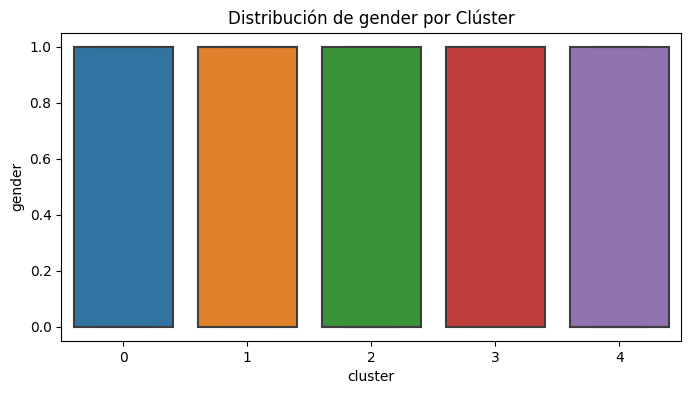

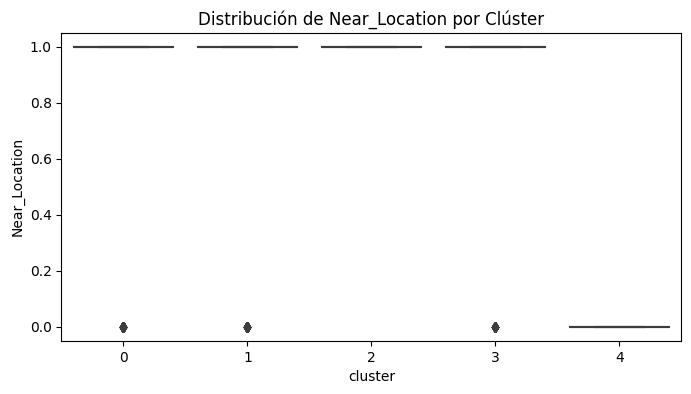

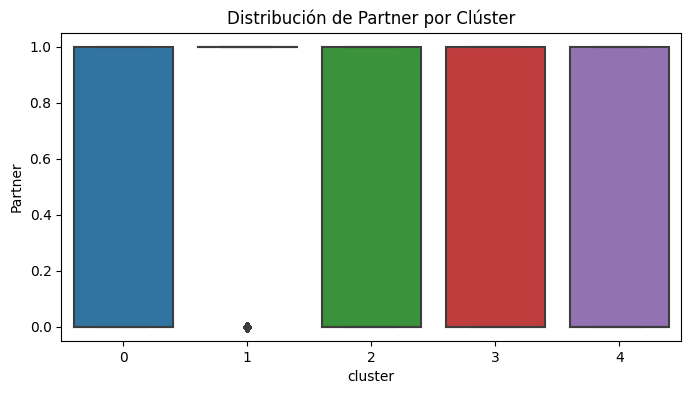

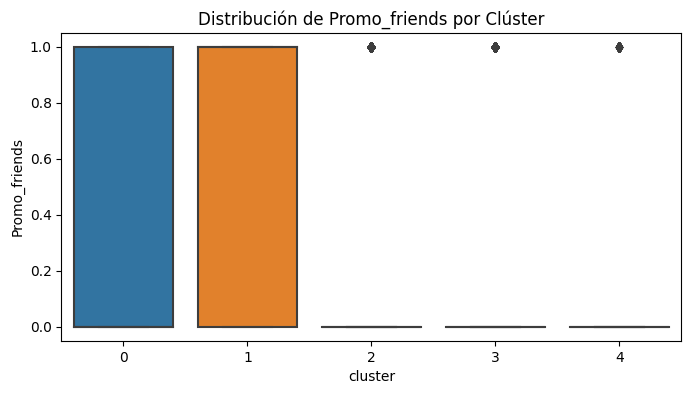

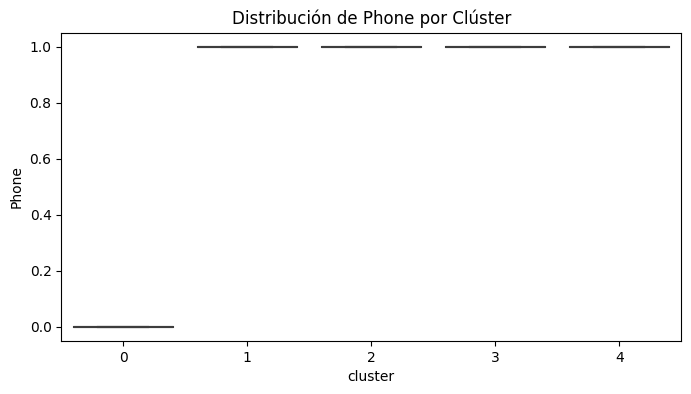

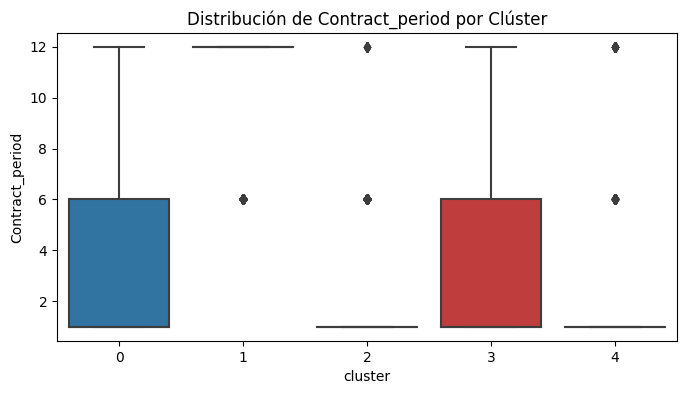

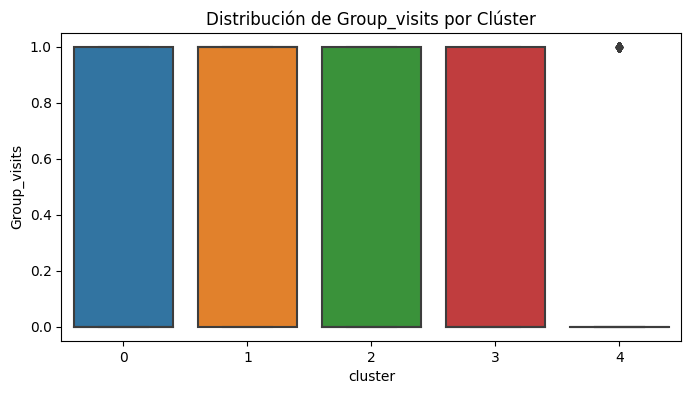

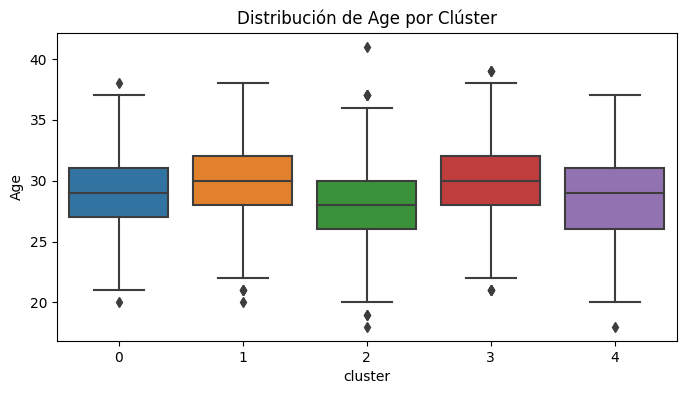

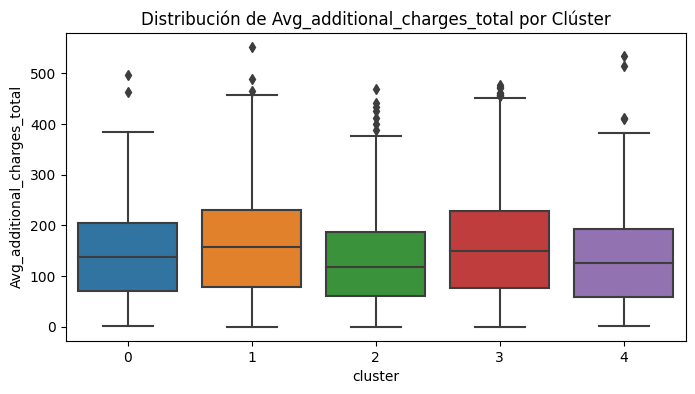

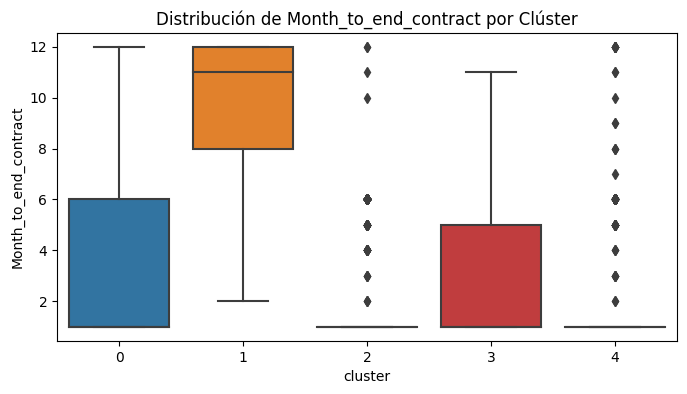

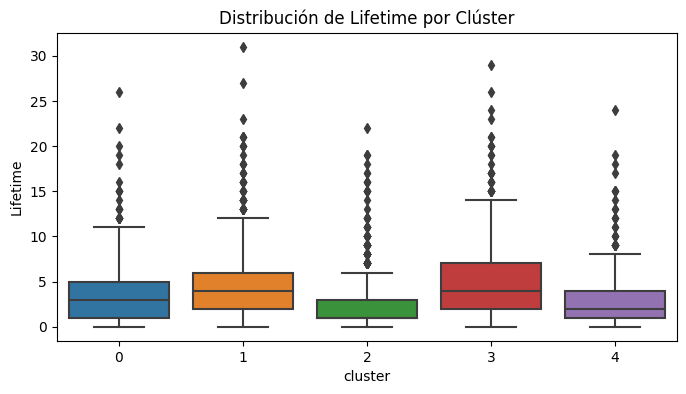

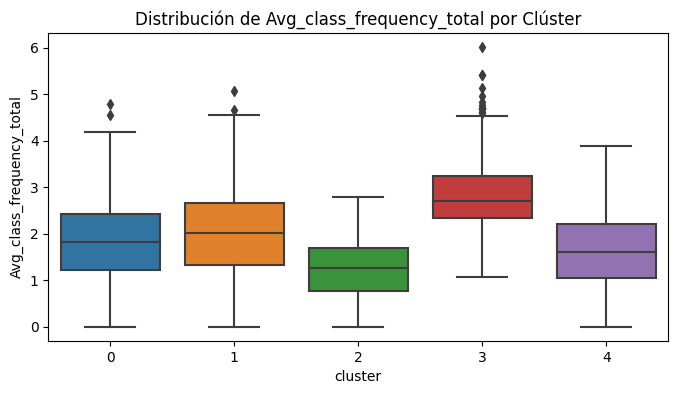

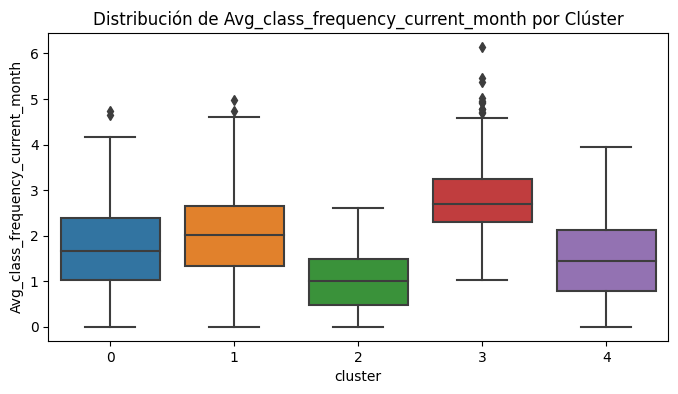

In [ ]:
for col in df.drop(columns=['Churn', 'cluster']).columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='cluster', y=col, data=df)
    plt.title(f'Distribución de {col} por Clúster')
    plt.show()

**Conclusiones:**

Patrones observables en las distribuciones de características por clústeres:

1. Frecuencia de clases: un fuerte diferenciador
- Clústeres como el 3 y el 0 tienen distribuciones elevadas y consistentes en frecuencia total y actual de clases.
- En cambio, el clúster 4 presenta valores bajos y dispersos, lo que coincide con su alta tasa de cancelación.

Interpretación: El hábito de asistir con constancia es el mejor predictor de permanencia.

2. Lifetime y Month_to_end_contract: ciclos opuestos
- Clúster 0 y 3 muestran lifetime más largo y meses restantes altos, reflejando compromisos sostenidos.
- Clústeres 4 y 1 tienen lifetime corto y contratos por terminar.

Interpretación: Cuanto más profundo el ciclo del cliente, mayor fidelidad.

3. Edad y cargos adicionales: perfiles con poder de inversión
- Algunos clústeres agrupan clientes mayores y con gasto elevado en servicios complementarios.

Interpretación: La inversión económica parece correlacionarse con lealtad.

4. Variables sociales (Near_Location, Partner, Promo_friends): capas de vinculación
- Clústeres fieles tienden a tener mayor presencia de vínculos sociales o cercanía geográfica.

Interpretación: Los vínculos externos fortalecen la conexión emocional con la experiencia.

### Tasa de cancelación por clúster

In [ ]:
cancel_rate = df.groupby('cluster')['Churn'].mean()
print(cancel_rate.sort_values(ascending=False))

cluster
2    0.521036
4    0.441815
0    0.266839
3    0.072261
1    0.027641
Name: Churn, dtype: float64


**Conclusiones:**

Los grupos identificados mediante clustering muestran diferencias significativas en su tendencia a cancelar su membresía. Las tasas varían notablemente, lo que sugiere distintos niveles de fidelidad y compromiso:

🔴 Altamente propensos a cancelar
- Cluster 4: 52.0%
- Cluster 1: 44.2%
Estos grupos son los más vulnerables. Más de la mitad del cluster 4 y casi la mitad del cluster 1 abandonan el servicio. Es probable que presenten contratos cortos, baja frecuencia de asistencia o escasa conexión emocional/social con la marca.

🟡 Moderadamente propensos
- Cluster 2: 26.7%
Este grupo representa una zona intermedia. Aunque la tasa no es crítica, tampoco es baja. Podrían ser susceptibles si no se refuerza su vínculo o motivación.

🟢 Poco propensos a cancelar
- Cluster 3: 7.2%
- Cluster 0: 2.8%
Estos clústeres son los más fieles. Sus tasas de cancelación son mínimas, posiblemente gracias a hábitos sólidos (como alta frecuencia de clases), vínculos sociales o contratos largos que sostienen su lealtad.

## Conclusiones y recomendaciones

**Conclusiones clave sobre la relación con los clientes:**

- La cercanía emocional y social influye más que la ubicación física.
- La constancia en la experiencia (visitas, clases, interacción) se traduce en lealtad.
- Los contratos cortos necesitan compensarse con vínculo emocional inmediato.
- La presencia de vínculos sociales (amigos, pareja) reduce la probabilidad de cancelación.

**Recomendaciones estratégicas de marketing:**

1. Crear rituales desde el primer mes
- Pasos: Diseñar una campaña de “primeros 30 días” con experiencias simbólicas como “Mi primera clase” o “Reto personal”.
- Impacto: Activa emocionalmente a los nuevos clientes para que sientan pertenencia desde el inicio.
2. Fomentar vínculos sociales
- Pasos: Incentivar las inscripciones en dúo, clases para grupos pequeños o recompensas por traer amigos.
- Impacto: Aumenta el apego emocional y reduce la sensación de anonimato.
3. Segmentar acciones por clústeres
- Pasos: Dirigir mensajes diferentes para clientes intensos, intermedios y propensos a cancelar (e.g., recordatorios emotivos para unos, promociones para otros).
- Impacto: Mejorar la eficacia del marketing y personaliza la experiencia sin saturar.
4. Celebrar la constancia
- Pasos: Reconocer a quienes cumplen metas o asisten regularmente con distintivos simbólicos (pulseras, trofeos internos).
- Impacto: Refuerza positivamente el hábito, generando orgullo y comunidad.